Loading data from openspace_assets/desi_catalog_boosted.csv...
Successfully loaded 854066 galaxies!


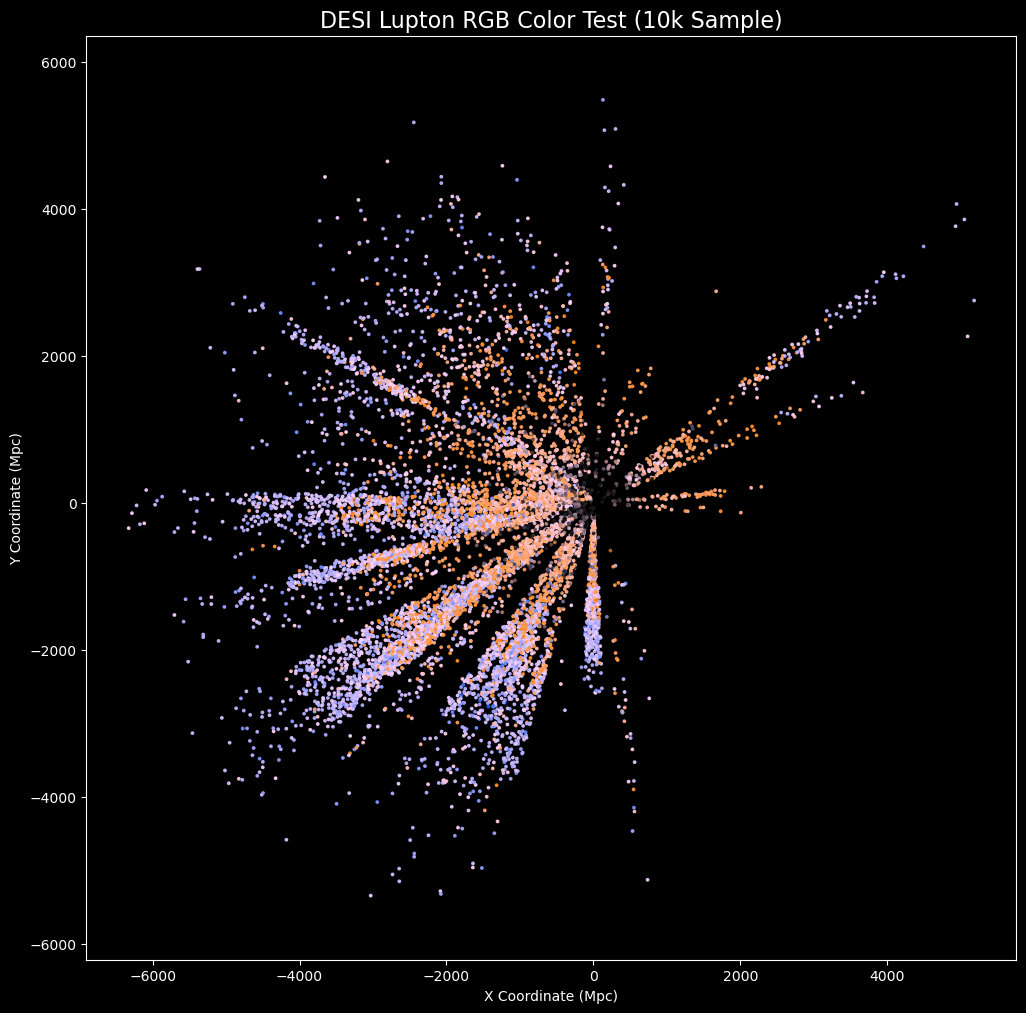

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Point it to the CSV you just generated
csv_path = 'openspace_assets/desi_catalog_boosted.csv'

print(f"Loading data from {csv_path}...")
table = Table.read(csv_path, format='csv')
print(f"Successfully loaded {len(table)} galaxies!")

# 1. Take a random sample so we don't crash the browser tab!
sample_size = 10000
sample_size = min(sample_size, len(table)) # Just in case the table is smaller

# Generate random indices and extract the sample
rng = np.random.default_rng()
sample_indices = rng.choice(len(table), size=sample_size, replace=False)
sampled_table = table[sample_indices]

# 2. Extract coordinates
x_plot = sampled_table['x']
y_plot = sampled_table['y']

# 3. Format the colors for Matplotlib
# Matplotlib expects a specific format: an array of [R, G, B] lists
colors = np.column_stack((
    sampled_table['color_r'], 
    sampled_table['color_g'], 
    sampled_table['color_b']
))

# 4. Create the plot!
# A dark background makes the space colors pop just like they will in OpenSpace
plt.style.use('dark_background')
plt.figure(figsize=(12, 12))

# Plot the scatter. 'c' applies our custom colors, 's' is the dot size.
plt.scatter(x_plot, y_plot, c=colors, s=3, alpha=0.9)

plt.title("DESI Lupton RGB Color Test (10k Sample)", fontsize=16)
plt.xlabel("X Coordinate (Mpc)")
plt.ylabel("Y Coordinate (Mpc)")

# Ensure the axes are scaled equally so the map isn't warped
plt.axis('equal') 
plt.show()

# Reset to default style so it doesn't mess up any future standard plots
plt.style.use('default')